In [55]:
!pip install pandas
!pip install numpy
!pip install sklearn
!pip install seaborn
!pip install matplotlib

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [57]:
!pip install scikit-learn


In [58]:
datas = sns.load_dataset('titanic')
data['deck'] = datas['deck']

In [59]:
data = sns.load_dataset('titanic')
print(data.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [60]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


<Axes: >

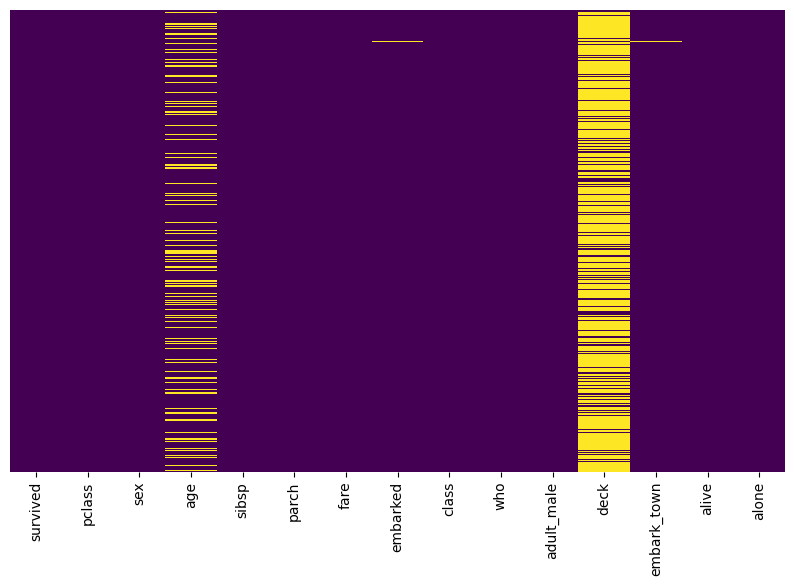

In [61]:
plt.figure(figsize=(10,6))
sns.heatmap(data.isnull(),yticklabels=False,cbar = False,cmap='viridis')


**clean all the data first then check for the duplicate values and else thing**

In [62]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [64]:
print(np.unique(data['pclass'])) #univariat analysis
print(np.unique(data['deck']))

[1 2 3]


TypeError: '<' not supported between instances of 'str' and 'float'

In [66]:
# pd.crosstab(data['deck'],data['survived'])  # bivariant and multivariant analysis   #deck has significant effect so we will improve it as A B desk are more clode to lifeboats
# pd.crosstab(data['age'],data['survived'])  # as age is too vary we will drop this
# pd.crosstab(data['sibsp'],data['survived'])  # also consider it as it has 9 different classes so reduce it as suitable for better model performance
# pd.crosstab(data['parch'],data['survived']) # same as one above sibsp
pd.crosstab(data['fare'],data['survived']) # drope this no significant effect

KeyError: 'fare'

In [67]:
# CORRECT: To select multiple columns, use double brackets
dropcolumns = data[['alive','class','embark_town','age','fare']]
data.drop(dropcolumns , inplace = True , axis = 1)

KeyError: "None of [Index(['alive', 'class', 'embark_town', 'age', 'fare'], dtype='object')] are in the [columns]"

In [72]:

data.head()

,survived,pclass,sex,embarked,who,adult_male,deck,alone,total_member
0,0,3,male,S,man,True,empty,False,2
1,1,1,female,C,woman,False,less,False,2
2,1,3,female,S,woman,False,empty,True,1
3,1,1,female,S,woman,False,less,False,2
4,0,3,male,S,man,True,empty,True,1


In [69]:
# for deck column
pd.crosstab(data['deck'],data['survived'])
data['deck']=data['deck'].apply(
    lambda x: 'most' if x in ['B', 'D', 'E'] else
              ('less' if x in ['A', 'C', 'F', 'G'] else 'empty')
)


In [70]:
data['deck'] = data['deck'].apply(
    lambda x: 'empty' if pd.isna(x) else x
)

In [71]:
# for the sibsp column and parch column best solution is to add them then category them
# pd.crosstab(data['sibsp'],data['survived'])
# data['sibsp'].isnull().sum()
data['total_member']= data['sibsp'] + data['parch'] + 1
dropped_columns = ['sibsp','parch']
data.drop(dropped_columns,inplace=True,axis=1)
# pd.crosstab(data['total_member'],data['survived'])
# If total_member contains integers (most likely)
# data['total_member'] = data['total_member'].apply(
#     lambda x: 'no_survival' if x in [8, 11] else (  # Use integers, not strings
#         'most_dead' if x in [5, 7, 6, 1] else (
#             'most_survival' if x in [2, 3, 4] else x
#         )
#     )
# )


In [73]:
data.drop_duplicates(keep=False, inplace=True)
data.dropna(inplace=True)

In [91]:
data.head()
data.shape

(78, 9)

In [77]:
# CONVERT ALL COLUMNS TO INT WHICH IS BEST FOR THE CLASSIFICATION


from sklearn.preprocessing import LabelEncoder
# Initialize a dictionary to store enco ders (useful for inverse transforms later)
label_encoders = {}

for col in ['sex', 'embarked','deck','who','total_member','survived','pclass','adult_male','alone']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))  # Convert to string to handle NaN
    label_encoders[col] = le  # Store the encoder for future use



In [79]:
# we will normalize data after the train_test split
x = data.drop('survived',axis=1)
y  = data['survived']
from sklearn.model_selection import train_test_split
x_train , x_test ,y_train , y_test = train_test_split(x , y , test_size =0.20 ,random_state=101 )

In [80]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)

# Step 4: Transform test data (using same scaling parameters)
x_test_scaled = scaler.transform(x_test)

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

le = LogisticRegression()
le.fit(x_train,y_train)

LogisticRegression()

In [86]:
y_pred = le.predict(x_test)

In [87]:
from sklearn.metrics import classification_report, accuracy_score
print('Classification Model')
print('--'*30)
logreg_accuracy = round(accuracy_score(y_test, y_pred)*100, 2)
print('Accuracy', logreg_accuracy, '%')


Classification Model
------------------------------------------------------------
Accuracy 37.5 %
